In [1]:
# prompt: read excel file with a specific sheet.

import pandas as pd

# Install openpyxl if you haven't already
#!pip install openpyxl

# Replace 'your_file.xlsx' with the actual filename
# Replace 'Sheet1' with the name of the sheet you want to read
df = pd.read_excel('/content/sample_data/data.xlsx'
, sheet_name='Sheet9',usecols=['order_id'
, 'shop_guid', 'app_source','order_time','distance_km','queue_size','prep_ahead_sum_min','prep_time_min','traffic_sec','rain_flag','eta_actual_sec'] )
# Now you can work with the DataFrame 'df'
df.head()


,order_id,shop_guid,app_source,order_time,distance_km,queue_size,prep_ahead_sum_min,prep_time_min,traffic_sec,rain_flag,eta_actual_sec
0,ORD900000,SHOP_007,ShopeeFood,2025-04-28 01:04:49.000000,2.72,3.0,8.0,7.0,349.0,0.0,1260.0
1,ORD900001,SHOP_056,LINE_MAN,2025-04-28 07:08:04.000000,6.80,4.0,11.0,4.0,874.0,0.0,1788.0
2,ORD900002,SHOP_059,LINE_MAN,2025-04-27 18:17:48.000000,0.89,5.0,17.0,8.0,114.0,0.0,1626.0
3,ORD900003,SHOP_018,GrabFood,2025-04-27 16:56:23.000000,1.17,3.0,6.0,3.0,150.0,0.0,720.0
4,ORD900004,SHOP_055,GrabFood,2025-04-27 19:40:53.000000,7.45,1.0,4.0,4.0,957.0,0.0,1428.0


In [2]:
# prompt: regress with output as ETA, give report for the performance, joint and individual test.

import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Load the data (assuming you've already loaded it into 'df')
# ... (your existing code to load the data) ...

# Define the dependent and independent variables
#ตัวแปลต้น
independent_variables = ['distance_km','queue_size','prep_ahead_sum_min','prep_time_min','traffic_sec','rain_flag']  # Replace with your actual independent variables
#ตัวแปลตาม
dependent_variable = 'eta_actual_sec'

# Create the regression formula
formula = f"{dependent_variable} ~ {' + '.join(independent_variables)}"

# Fit the OLS model(Ordinary Least Squares) หาค่าCoefficientsที่ดีที่สุดและทำให้Error Squareน้อยที่สุด
model = smf.ols(formula, data=df).fit()

# Print the regression summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:         eta_actual_sec   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                 3.890e+05
Date:                Wed, 30 Apr 2025   Prob (F-statistic):               0.00
Time:                        02:32:32   Log-Likelihood:            -5.9193e+05
No. Observations:              100000   AIC:                         1.184e+06
Df Residuals:                   99993   BIC:                         1.184e+06
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.8247      0

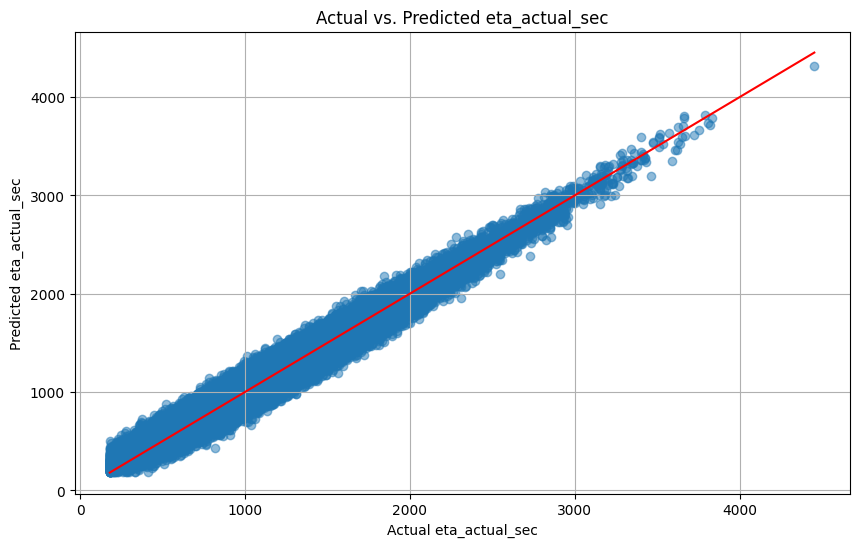

In [3]:
# prompt: Jus plot the dependent variable compared with the regressed result.

import matplotlib.pyplot as plt

# Predict the dependent variable using the fitted model
df['predicted_eta'] = model.predict(df)

# Create the plot
plt.figure(figsize=(10, 6))
plt.scatter(df[dependent_variable], df['predicted_eta'], alpha=0.5)
plt.xlabel(f"Actual {dependent_variable}")
plt.ylabel(f"Predicted {dependent_variable}")
plt.title(f"Actual vs. Predicted {dependent_variable}")
plt.plot([min(df[dependent_variable]), max(df[dependent_variable])], [min(df[dependent_variable]), max(df[dependent_variable])], color='red') # Add a diagonal line for reference
plt.grid(True)
plt.show()


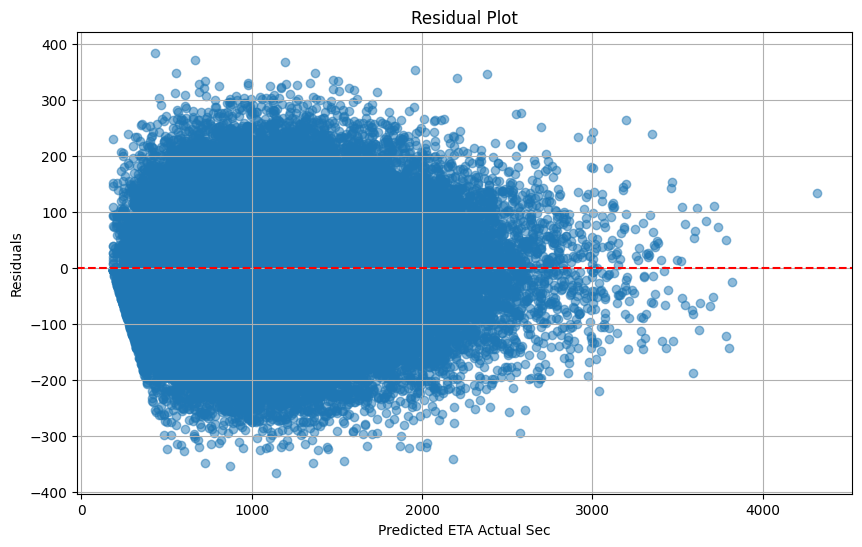

In [4]:
import matplotlib.pyplot as plt

# Get predicted values from the model using the original dataframe index
predicted_values = model.predict(df)
# Note that model.predict() might have fewer values than your original df if there were missing values.
# We'll use the original df index to align the predicted values with the residuals
predicted_values = predicted_values.reindex(df.index)

residuals = model.resid
# Ensure residuals are aligned with the dataframe index
residuals = residuals.reindex(df.index)

# Create the residual plot, using a shared index
plt.figure(figsize=(10, 6))
plt.scatter(predicted_values, residuals, alpha=0.5)
plt.xlabel("Predicted ETA Actual Sec")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.axhline(y=0, color='red', linestyle='--')  # Add a horizontal line at y=0
plt.grid(True)
plt.show()

In [6]:
from scipy.stats import shapiro

# Assuming 'residuals' are your model residuals
stat, p = shapiro(residuals)
print('Shapiro-Wilk Statistic: %.3f, p-value: %.3f' % (stat, p))

# Interpret the results
alpha = 0.05  # Significance level
if p > alpha:
    print('Residuals appear to be normally distributed (fail to reject H0)')
else:
    print('Residuals do not appear to be normally distributed (reject H0)')

Shapiro-Wilk Statistic: nan, p-value: nan
Residuals do not appear to be normally distributed (reject H0)


In [7]:
df.head(10)

,order_id,shop_guid,app_source,order_time,distance_km,queue_size,prep_ahead_sum_min,prep_time_min,traffic_sec,rain_flag,eta_actual_sec,predicted_eta
0,ORD900000,SHOP_007,ShopeeFood,2025-04-28 01:04:49.000000,2.72,3.0,8.0,7.0,349.0,0.0,1260.0,1242.968014
1,ORD900001,SHOP_056,LINE_MAN,2025-04-28 07:08:04.000000,6.80,4.0,11.0,4.0,874.0,0.0,1788.0,1761.861119
2,ORD900002,SHOP_059,LINE_MAN,2025-04-27 18:17:48.000000,0.89,5.0,17.0,8.0,114.0,0.0,1626.0,1560.065847
3,ORD900003,SHOP_018,GrabFood,2025-04-27 16:56:23.000000,1.17,3.0,6.0,3.0,150.0,0.0,720.0,707.960847
4,ORD900004,SHOP_055,GrabFood,2025-04-27 19:40:53.000000,7.45,1.0,4.0,4.0,957.0,0.0,1428.0,1418.280838
5,ORD900005,SHOP_031,LINE_MAN,2025-04-27 15:01:35.000000,6.57,1.0,5.0,3.0,1098.0,1.0,1722.0,1666.481259
6,ORD900006,SHOP_056,GrabFood,2025-04-27 17:59:13.000000,1.79,2.0,4.0,8.0,230.0,0.0,906.0,961.992118
7,ORD900007,SHOP_010,LINE_MAN,2025-04-27 17:51:14.000000,6.79,3.0,7.0,6.0,1134.0,0.0,1800.0,1919.929671
8,ORD900008,SHOP_021,LINE_MAN,2025-04-27 21:23:32.000000,1.67,3.0,9.0,2.0,214.0,0.0,810.0,855.642711
9,ORD900009,SHOP_030,GrabFood,2025-04-27 11:38:15.000000,3.63,2.0,6.0,4.0,466.0,0.0,1194.0,1053.575432


In [8]:
#Save model
import joblib

joblib.dump(model, 'eta_model.pkl')

['eta_model.pkl']

In [10]:
#Predict
import pandas as pd
import joblib

# 1) โหลดโมเดลจากไฟล์
pipe = joblib.load('eta_model.pkl')

# 2) ระบุชื่อคอลัมน์ตัวแปรต้นให้ตรงกับตอนฝึก
independent_variables = [
    'distance_km',
    'queue_size',
    'prep_ahead_sum_min',
    'prep_time_min',
    'traffic_sec',
    'rain_flag'
]

# 3) เตรียมข้อมูลออเดอร์ใหม่
new_orders = pd.DataFrame([{
    'distance_km':       2.72,
    'queue_size':        3,
    'prep_ahead_sum_min': 8,
    'prep_time_min':     7,
    'traffic_sec':       349,
    'rain_flag':         0
}], columns=independent_variables)

eta_pred = pipe.predict(new_orders)[0]

# กำหนดช่วง ±5 นาที
low  = eta_pred - 5
high = eta_pred + 5

# แสดงผล
minutes = int(eta_pred // 60)      # หารเอาเฉพาะจำนวนเต็ม
seconds = int(eta_pred % 60)       # หารเอาเศษ
print(f"ETA คาด ≈ {minutes} นาที {seconds} วินาที")

offset = 5 * 60           # 5 นาที = 300 วินาที
low = eta_pred - offset   # ค่าต่ำสุด
high = eta_pred + offset  # ค่าสูงสุด

# แปลงเป็น นาที กับ วินาที
low_min  = int(low // 60)
low_sec  = int(low % 60)
high_min = int(high // 60)
high_sec = int(high % 60)

print(f"ETA อยู่ระหว่าง {low_min} นาที {low_sec} วินาที",f"- {high_min} นาที {high_sec} วินาที")



ETA คาด ≈ 20 นาที 42 วินาที
ETA อยู่ระหว่าง 15 นาที 42 วินาที - 25 นาที 42 วินาที


Note that when dropping Intercept the R2 will be based on different basis (uncertered on mean) than the normal case, so they are not comparable.